# Pipeline: 2D bubble at finite charge (fixed ω)

## 0. Title + Overview

**Fixed ω (chemical potential):** We work in the grand-canonical setup where ω is fixed. The effective potential for the saddle is the **grand potential** Ω(φ) = V(φ) − ω²φ². As ω increases, the −ω²φ² term tilts the potential and can merge or shift the two minima.

**Homogeneous configuration:** The field is constant in space, φ = ρ₀, with ρ₀ determined by stationarity of Ω (dΩ/dφ = 0 ⇒ dV/dφ = 2ω²φ at ρ₀). This is the metastable “false vacuum” at finite density.

**What we compare:** We compare **energy E** and **charge Q** of:
- The homogeneous configuration at a reference ω = ω₀
- 1D O(3) radial bubble profiles at the same or different ω
- 2D (τ, r) solutions from Newton (homogeneous seed vs gated bubble seed)

**1D vs 2D:** The 1D O(3) bounce solves φ″ + (2/r)φ′ = dΩ/dφ on the radial line; it is τ-independent. The 2D problem is on the half Euclidean-time interval τ ∈ (−β/2, 0) with twist closure at τ = −β/2; the Newton solver finds a (τ, r)-dependent saddle that can be compared to the homogeneous and 1D bubble in Q and E.

## 1. Imports + Project Setup

In [57]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.interpolate import interp1d

from Q_ball_finder.grid import build_grid, RadialTimeGrid
from Q_ball_finder.notebook_utils import resample_complex_field
from Bubble_finder.potential_bubble import (
    V_phi, dV_dphi, d2V_dphi2, Omega_phi, dOmega_dphi, vacua_of_Omega,
)
from Bubble_finder.bounce2d import (
    Bubble2DSettings, Bubble2DSolver, make_potential_from_V, solve_rho0_for_omega,
    NewtonConvergenceError,
)
from Bubble_finder.bounce_1d import solve_bounce
from Bubble_finder.observables_1d import (
    compute_charge, compute_energy, Q_homogeneous_ball,
    compute_charge_1d_volume_corrected,
)
from Bubble_finder.observables_2d import (
    compute_targets_tau0_ghost, compute_observables_tau0_ghost,
    homogeneous_energy_2d,
)
from Bubble_finder.ansatz_bubble import tau_gate, AnsatzParams, make_bubble_profile_1d_from_arrays
from scipy.optimize import brentq, root_scalar

Path("./figures").mkdir(parents=True, exist_ok=True)
Path("./data_out").mkdir(parents=True, exist_ok=True)

CONFIG = {
    "phi0": 1.999,
    "v1": 1.0,
    "v2": 2.0,
    "omega0":0.85,
    "Lr": 10.0,
    "beta": 40.0,
    "Nr": 80,
    "Ntau": 160,
    "omega_scan_min": 0.1,
    "omega_scan_max": 0.9,
    "omega_scan_N": 30,
    "beta_big": 60.0,
    "Lr_big": 35.0,
    "Nr_big": 120,
    "Nt_big": 240,
    "newton_tol": 1e-9,
    "newton_max_iter": 35,
    "eta_scan_d_eta": 0.02,
    "eta_scan_tol_Q": 1e-6,
    "gated_tau_gate_frac": 0.2,
    "gated_tau_gate_center_frac": 0.5,
    "use_omega_Qmatch_for_gated": True,
}

U, dU, d2U = make_potential_from_V(V_phi, dV_dphi, d2V_dphi2,
    phi0=CONFIG["phi0"], v1=CONFIG["v1"], v2=CONFIG["v2"])
params = {"phi0": CONFIG["phi0"], "v1": CONFIG["v1"], "v2": CONFIG["v2"]}

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
print("CONFIG and potential ready. figures/ and data_out/ created.")

CONFIG and potential ready. figures/ and data_out/ created.


## 2. Model Definition: Potential and ω-deformed effective potential

### 2.1 Formulas (same as in the codebase)

**Potential V(φ):**
$$V(\phi) = -\frac{1}{2} + (\phi-1)^2\left[2\phi - 5 + (2-\phi)^2 \ln\frac{(2-\phi)^2(\phi_0-1)^2}{(\phi-1)^2(\phi_0-2)^2}\right]$$
with φ₀ = 1.999, false vacuum at v₁ = 1, true at v₂ = 2.

**Grand potential (effective potential at fixed ω):**
$$\Omega(\phi) = V(\phi) - \omega^2\phi^2\,.$$
The saddle-point equation uses dΩ/dφ; the two minima of Ω (false and true) are found by the code via `vacua_of_Omega`.

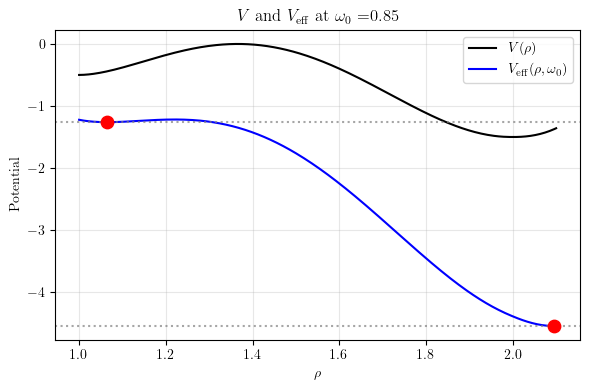

In [58]:
def V_rho(rho, params):
    return V_phi(rho, params["phi0"], params["v1"], params["v2"])

def Veff_rho(rho, omega, params):
    return Omega_phi(rho, params["phi0"], params["v1"], params["v2"], omega)

omega0 = CONFIG["omega0"]
phi_false_omega0, phi_true_omega0 = vacua_of_Omega(
    CONFIG["phi0"], CONFIG["v1"], CONFIG["v2"], omega0, verbose=False)

V_false = float(Veff_rho(phi_false_omega0, omega0, params))
V_true = float(Veff_rho(phi_true_omega0, omega0, params))
minima_omega0 = {
    "omega": omega0,
    "rho_false": phi_false_omega0,
    "rho_true": phi_true_omega0,
    "Veff_false": V_false,
    "Veff_true": V_true,
    "labels": ("false/homogeneous", "true/inside bubble"),
}

rho_plot = np.linspace(1.0, 2.1, 300)
V_plot = V_rho(rho_plot, params)
Veff_plot = Veff_rho(rho_plot, omega0, params)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(rho_plot, V_plot, "k-", label=r"$V(\rho)$")
ax.plot(rho_plot, Veff_plot, "b-", label=r"$V_{\mathrm{eff}}(\rho,\omega_0)$")
ax.scatter([phi_false_omega0, phi_true_omega0], [V_false, V_true], color="red", s=80, zorder=5)
ax.axhline(V_false, color="gray", ls=":", alpha=0.7)
ax.axhline(V_true, color="gray", ls=":", alpha=0.7)
ax.set_xlabel(r"$\rho$")
ax.set_ylabel(r"Potential")
ax.legend()
ax.set_title(r"$V$ and $V_{\mathrm{eff}}$ at $\omega_0 = $" + f"{omega0}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("./figures/potential_omega0.png", dpi=150)
plt.show()

## 3. Energy and Charge: homogeneous and 1D bubble at fixed ω₀

### 3.1 Formulas (as in the code)

**Charge:** $Q = 4\pi\,\omega\int_0^{r_{\max}}\! r^2\phi^2\,\mathrm{d}r$ (1D); same convention in 2D with ghost reconstruction at τ=0.

**Energy (1D O(3) bounce):** $E[\phi] = 4\pi\int_0^\infty\! r^2\bigl[\tfrac{1}{2}(\partial_r\phi)^2 + \Omega(\phi)\bigr]\mathrm{d}r$. The code uses **reference energy**: subtract Ω(φ_false) so the homogeneous configuration has zero energy (subtract_background=True in `compute_energy`). So $E_{\mathrm{ref}} = 4\pi\int r^2[\tfrac{1}{2}(\partial_r\phi)^2 + \Omega(\phi)-\Omega(\phi_{\mathrm{false}})]\mathrm{d}r$.

**Volume:** $V = \frac{4}{3}\pi\,L_r^3$ with $L_r = r_{\max}$.

In [59]:
def compute_QE_hom(omega0_val, Lr_val, params, U, rho0=None):
    if rho0 is None:
        rho0 = float(solve_rho0_for_omega(omega0_val, U, (params["v1"] - 0.2, params["v2"] + 0.2)))
    else:
        rho0 = float(rho0)
    Q = Q_homogeneous_ball(omega0_val, rho0, Lr_val)
    E = homogeneous_energy_2d(omega0_val, rho0, Lr_val, U)
    volume = (4.0 / 3.0) * np.pi * (Lr_val**3)
    return Q, E, volume, rho0

Lr = CONFIG["Lr"]
omega0 = CONFIG["omega0"]
Q_hom_omega0, E_hom_omega0, volume_hom, rho0_hom = compute_QE_hom(omega0, Lr, params, U, rho0=phi_false_omega0)

hom_omega0 = {
    "omega": omega0,
    "rho": rho0_hom,
    "Q": Q_hom_omega0,
    "E": E_hom_omega0,
    "volume": volume_hom,
    "details": {"Lr": Lr, "phi_false": phi_false_omega0},
}
assert np.isfinite(Q_hom_omega0) and np.isfinite(E_hom_omega0)
print(f"Homogeneous at omega0={omega0}: rho0_hom={rho0_hom:.6e}, Q={Q_hom_omega0:.6e}, E={E_hom_omega0:.6e}, volume={volume_hom:.4e}")

Homogeneous at omega0=0.85: rho0_hom=1.065039e+00, Q=4.038670e+03, E=-1.584151e+03, volume=4.1888e+03


In [60]:
def solve_bubble_O3(omega_val, params, extend_to=None, n_grid_points=800):
    r_grid, phi_grid, phi0_f, phi_false, phi_true = solve_bounce(
        CONFIG["phi0"], CONFIG["v1"], CONFIG["v2"], omega_val,
        d=3, r0=1e-8, rmax=10,
        verbose=False, extend_to=extend_to, n_grid_points=n_grid_points)
    if r_grid is None:
        return None
    return {
        "r": r_grid, "phi": phi_grid,
        "phi_false": phi_false, "phi_true": phi_true,
    }

def _extend_profile_to_Lr(r, phi, Lr_val, phi_false_tail):
    """Extend (r, phi) to [0, Lr]: if r[-1] < Lr append tail at phi_false_tail; if r[-1] > Lr truncate."""
    r, phi = np.asarray(r, dtype=float), np.asarray(phi, dtype=float)
    r_max = float(r[-1])
    if r_max >= Lr_val - 1e-12:
        mask = r <= Lr_val
        r_use, phi_use = r[mask], phi[mask]
        if r_use[-1] < Lr_val - 1e-12:
            r_use = np.append(r_use, Lr_val)
            phi_use = np.append(phi_use, np.interp(Lr_val, r, phi))
        return r_use, phi_use
    r_ext = np.append(r, Lr_val)
    phi_ext = np.append(phi, phi_false_tail)
    return r_ext, phi_ext

def compute_QE_1d(profile, params, omega_val, phi_false, Lr_ref=None, subtract_background=False):
    r, phi = profile["r"], profile["phi"]
    Lr_use = float(Lr_ref) if Lr_ref is not None else float(r[-1])
    if abs(r[-1] - Lr_use) > 1e-10:
        Q = compute_charge_1d_volume_corrected(r, phi, omega_val, Lr_use, phi_false)
        r_ext, phi_ext = _extend_profile_to_Lr(r, phi, Lr_use, phi_false)
        E = compute_energy(r_ext, phi_ext, params["phi0"], params["v1"], params["v2"],
                           omega_val, phi_false, subtract_background=subtract_background)
    else:
        Q = compute_charge(r, phi, omega_val)
        E = compute_energy(r, phi, params["phi0"], params["v1"], params["v2"],
                           omega_val, phi_false, subtract_background=subtract_background)
    return Q, E

bub1d = solve_bubble_O3(omega0, params, extend_to=Lr)
if bub1d is None:
    raise RuntimeError("1D O(3) bubble at omega0 failed.")
Q_bub1d_omega0, E_bub1d_omega0 = compute_QE_1d(bub1d, params, omega0, bub1d["phi_false"], Lr_ref=Lr)

bub1d_omega0 = {
    "omega": omega0,
    "profile": bub1d,
    "Q": Q_bub1d_omega0,
    "E": E_bub1d_omega0,
    "grid": bub1d["r"],
    "details": {"phi_false": bub1d["phi_false"], "phi_true": bub1d["phi_true"]},
}
print(f"1D bubble at omega0: Q={Q_bub1d_omega0:.6e}, E={E_bub1d_omega0:.6e}")

1D bubble at omega0: Q=4.041329e+03, E=-5.281061e+03


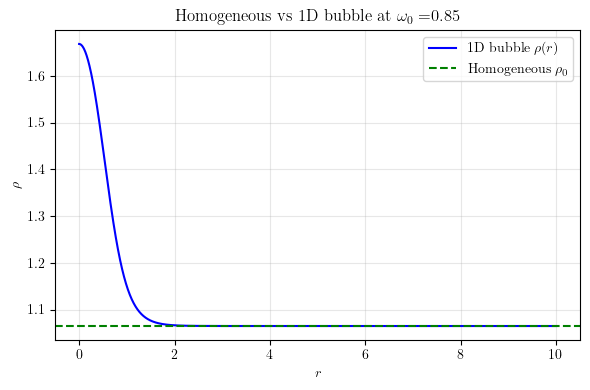

In [61]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
r_bub = bub1d_omega0["grid"]
phi_bub = bub1d_omega0["profile"]["phi"]
ax.plot(r_bub, phi_bub, "b-", label=r"1D bubble $\rho(r)$")
ax.axhline(rho0_hom, color="green", ls="--", label=r"Homogeneous $\rho_0$")
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$\rho$")
ax.legend()
ax.set_title(r"Homogeneous vs 1D bubble at $\omega_0 = $" + f"{omega0}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("./figures/bubble1d_omega0.png", dpi=150)
plt.show()

## 4. Scan in ω: O(3) bubble matching Q and matching E

In [62]:
from scipy.optimize import root_scalar

R_MAX_REF = Lr

def Q_bubble_at_omega(omega_tilde):
    """Charge of the 1D bubble at omega_tilde, volume-corrected to [0, R_MAX_REF]."""
    b = solve_bubble_O3(omega_tilde, params, extend_to=R_MAX_REF)
    if b is None:
        return np.nan
    return compute_charge_1d_volume_corrected(b["r"], b["phi"], omega_tilde, R_MAX_REF, b["phi_false"])

omega_lo = omega0 * 0.9
omega_hi = omega0
try:
    res_Q = root_scalar(lambda w: Q_bubble_at_omega(w) - Q_hom_omega0, bracket=[omega_lo, omega_hi], method="brentq")
    omega_Qmatch = res_Q.root
except ValueError:
    omega_lo = max(CONFIG["omega_scan_min"], 0.05)
    res_Q = root_scalar(lambda w: Q_bubble_at_omega(w) - Q_hom_omega0, bracket=[omega_lo, omega_hi], method="brentq")
    omega_Qmatch = res_Q.root

# Recompute bubble at omega_Qmatch once (as in bubble_2D)
bub1d_Qmatch = solve_bubble_O3(omega_Qmatch, params, extend_to=R_MAX_REF)
if bub1d_Qmatch is not None:
    Q_bubble_corrected = compute_charge_1d_volume_corrected(
        bub1d_Qmatch["r"], bub1d_Qmatch["phi"], omega_Qmatch, R_MAX_REF, bub1d_Qmatch["phi_false"]
    )
    _, E_bub = compute_QE_1d(bub1d_Qmatch, params, omega_Qmatch, bub1d_Qmatch["phi_false"], Lr_ref=R_MAX_REF)
    bub1d_Qmatch = {"omega": omega_Qmatch, "profile": bub1d_Qmatch, "Q": Q_bubble_corrected, "E": E_bub}
else:
    bub1d_Qmatch = {"omega": omega_Qmatch, "profile": None, "Q": np.nan, "E": np.nan}

omega_Ematch = omega0
bub1d_Ematch = solve_bubble_O3(omega_Ematch, params, extend_to=Lr)
if bub1d_Ematch is not None:
    Q_e, E_e = compute_QE_1d(bub1d_Ematch, params, omega_Ematch, bub1d_Ematch["phi_false"], Lr_ref=Lr)
    bub1d_Ematch = {"omega": omega_Ematch, "profile": bub1d_Ematch, "Q": Q_e, "E": E_e}
else:
    bub1d_Ematch = {"omega": omega_Ematch, "profile": None, "Q": np.nan, "E": np.nan}

# Light scan for plotting only (few points)
n_scan = min(20, CONFIG["omega_scan_N"])
omega_scan = np.linspace(CONFIG["omega_scan_min"], CONFIG["omega_scan_max"], n_scan)
Q_bub1d_scan = np.full_like(omega_scan, np.nan)
E_bub1d_scan = np.full_like(omega_scan, np.nan)
ok_mask_scan = np.zeros(len(omega_scan), dtype=bool)
profiles_scan = []
for i, om in enumerate(omega_scan):
    try:
        b = solve_bubble_O3(om, params, extend_to=Lr)
        if b is None:
            continue
        Q_bub1d_scan[i], E_bub1d_scan[i] = compute_QE_1d(b, params, om, b["phi_false"], Lr_ref=Lr)
        ok_mask_scan[i] = True
        profiles_scan.append((om, b))
    except Exception:
        pass

def get_bub1d_at_omega(om):
    b = solve_bubble_O3(om, params, extend_to=Lr)
    if b is None:
        return None
    Q, E = compute_QE_1d(b, params, om, b["phi_false"], Lr_ref=Lr)
    return {"omega": om, "profile": b, "Q": Q, "E": E}

Q_bub_at_Qmatch = bub1d_Qmatch["Q"] if bub1d_Qmatch["profile"] is not None else np.nan
print(f"omega_Qmatch = {omega_Qmatch:.6f}, omega_Ematch = {omega_Ematch:.6f}")
print(f"Q match: |Q_bubble - Q_hom| = {abs(Q_bub_at_Qmatch - Q_hom_omega0):.2e}")

omega_Qmatch = 0.849617, omega_Ematch = 0.850000
Q match: |Q_bubble - Q_hom| = 7.59e-05


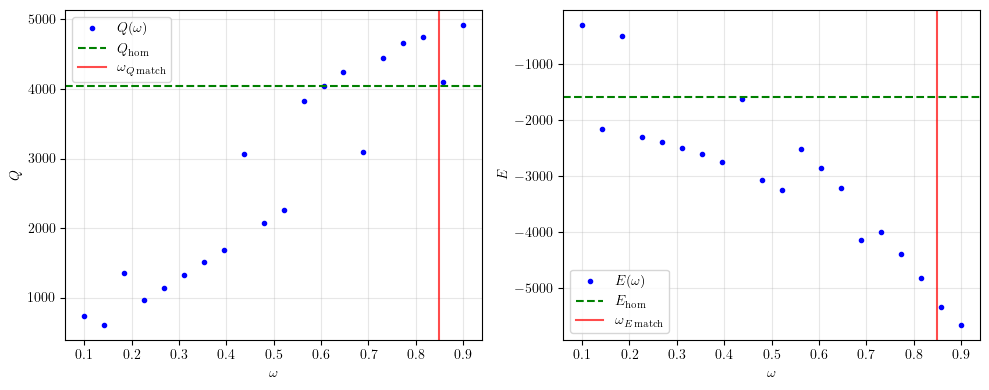

In [63]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(omega_scan[ok_mask_scan], Q_bub1d_scan[ok_mask_scan], "b.", label=r"$Q(\omega)$")
ax1.axhline(Q_hom_omega0, color="green", ls="--", label=r"$Q_{\mathrm{hom}}$")
ax1.axvline(omega_Qmatch, color="red", alpha=0.7, label=r"$\omega_{Q\,\mathrm{match}}$")
ax1.set_xlabel(r"$\omega$")
ax1.set_ylabel(r"$Q$")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(omega_scan[ok_mask_scan], E_bub1d_scan[ok_mask_scan], "b.", label=r"$E(\omega)$")
ax2.axhline(E_hom_omega0, color="green", ls="--", label=r"$E_{\mathrm{hom}}$")
ax2.axvline(omega_Ematch, color="red", alpha=0.7, label=r"$\omega_{E\,\mathrm{match}}$")
ax2.set_xlabel(r"$\omega$")
ax2.set_ylabel(r"$E$")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("./figures/scan_Q_E_vs_omega.png", dpi=150)
plt.show()

In [45]:
print(omega_scan)

[0.1        0.12758621 0.15517241 0.18275862 0.21034483 0.23793103
 0.26551724 0.29310345 0.32068966 0.34827586 0.37586207 0.40344828
 0.43103448 0.45862069 0.4862069  0.5137931  0.54137931 0.56896552
 0.59655172 0.62413793 0.65172414 0.67931034 0.70689655 0.73448276
 0.76206897 0.78965517 0.81724138 0.84482759 0.87241379 0.9       ]


## 5. Baselines at ω = 0: O(3) and O(4) bubbles

In [ ]:
def solve_bubble_O4(omega_val, params, extend_to=None, n_grid_points=800):
    r_grid, phi_grid, phi0_f, phi_false, phi_true = solve_bounce(
        CONFIG["phi0"], CONFIG["v1"], CONFIG["v2"], omega_val,
        d=4, r0=1e-6, rmax=min(200.0, (Lr or 30) * 2),
        verbose=False, extend_to=extend_to, n_grid_points=n_grid_points)
    if r_grid is None:
        return None
    return {"r": r_grid, "phi": phi_grid, "phi_false": phi_false, "phi_true": phi_true}

bubO3_0 = solve_bubble_O3(0.0, params, extend_to=Lr)
bubO4_0 = solve_bubble_O4(0.0, params, extend_to=Lr)

bubO3_omega0 = {"omega": 0.0, "profile": bubO3_0, "Q": np.nan, "E": np.nan}
if bubO3_0 is not None:
    bubO3_omega0["Q"], bubO3_omega0["E"] = compute_QE_1d(bubO3_0, params, 0.0, bubO3_0["phi_false"], Lr_ref=Lr)

bubO4_omega0 = {"omega": 0.0, "profile": bubO4_0, "action": np.nan, "details": {}}
if bubO4_0 is not None:
    from scipy.integrate import simpson
    r4, phi4 = bubO4_0["r"], bubO4_0["phi"]
    dphi = np.gradient(phi4, r4, edge_order=2)
    dphi[0] = 0.0
    V4 = np.array([V_rho(p, params) for p in phi4])
    integrand = 0.5 * dphi**2 + V4
    bubO4_omega0["action"] = float(2 * np.pi**2 * simpson(r4**3 * integrand, x=r4))
    bubO4_omega0["details"] = {"r": r4, "phi": phi4}

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(bub1d_omega0["grid"], bub1d_omega0["profile"]["phi"], "b-", label=r"O(3) $\omega_0$")
if bub1d_Qmatch.get("profile"):
    ax.plot(bub1d_Qmatch["profile"]["r"], bub1d_Qmatch["profile"]["phi"], "c-", label=r"O(3) $\omega_{Q\mathrm{match}}$")
if bub1d_Ematch.get("profile"):
    ax.plot(bub1d_Ematch["profile"]["r"], bub1d_Ematch["profile"]["phi"], "m-", label=r"O(3) $\omega_{E\mathrm{match}}$")
if bubO3_0 is not None:
    ax.plot(bubO3_0["r"], bubO3_0["phi"], "g-", label=r"O(3) $\omega=0$")
if bubO4_0 is not None:
    ax.plot(bubO4_0["r"], bubO4_0["phi"], "r-", label=r"O(4) $\omega=0$")
ax.axhline(rho0_hom, color="k", ls=":", alpha=0.5)
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$\rho$")
ax.legend()
ax.set_title(r"Radial profiles comparison")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("./figures/bubbles_comparison.png", dpi=150)
plt.show()

## 6. 2D problem: Ansatz A — homogeneous seed → Newton → resample → η scan

In [ ]:
def run_newton_2d(ansatz_x0, settings, U, dU, d2U, verbose=True):
    solver = Bubble2DSolver(settings, U, dU, d2U)
    try:
        sol = solver.solve(ansatz_x0, verbose=verbose, verbose_success_block=verbose)
        return solver, sol, None
    except NewtonConvergenceError as e:
        return solver, None, str(e)

omega0 = CONFIG["omega0"]
settings_hom = Bubble2DSettings(
    Nr=CONFIG["Nr"], Ntau=CONFIG["Ntau"], Lr=CONFIG["Lr"], beta=CONFIG["beta"],
    omega_ref=omega0, eta0=0.0, rho0_bracket=(params["v1"], params["v2"] + 0.2),
    newton_tol=CONFIG["newton_tol"], newton_max_iter=CONFIG["newton_max_iter"],
    complex_saddle=True, verbose=False)

solver_hom = Bubble2DSolver(settings_hom, U, dU, d2U)
ansatz2d_hom = {
    "fields": solver_hom._zero_vec(),
    "omega": omega0,
    "eta0": 0.0,
    "beta": CONFIG["beta"], "Lr": CONFIG["Lr"],
    "Nr": CONFIG["Nr"], "Ntau": CONFIG["Ntau"],
}
x0_hom = ansatz2d_hom["fields"]

In [ ]:
solver_hom = Bubble2DSolver(settings_hom, U, dU, d2U)
try:
    sol2d_hom = solver_hom.solve(x0_hom, verbose=False, verbose_success_block=False)
    sol2d_hom_dict = {
        "solution": sol2d_hom,
        "residual_norms": sol2d_hom.newton.history,
        "iterations": sol2d_hom.newton.iterations,
        "success": sol2d_hom.newton.success,
        "y": sol2d_hom.y, "ybar": sol2d_hom.ybar,
        "grid": solver_hom.grid,
    }
except NewtonConvergenceError as e:
    sol2d_hom_dict = {
        "solution": None, "residual_norms": [], "iterations": 0,
        "success": False, "y": None, "ybar": None, "grid": solver_hom.grid,
        "error": str(e),
    }
    print("Newton (homogeneous seed) failed:", e)

sol2d_hom = sol2d_hom_dict

In [ ]:
def resample_solution(sol, new_grid_params, U, dU, d2U):
    r_old = sol["grid"].r
    tau_old = sol["grid"].tau
    if hasattr(sol["grid"], "Ntau"):
        Nt_old = sol["grid"].Ntau
    else:
        Nt_old = len(tau_old)
    r_new = (np.arange(new_grid_params["Nr_big"]) + 1.0) * (new_grid_params["Lr_big"] / new_grid_params["Nr_big"])
    dtau_new = new_grid_params["beta_big"] / (2.0 * new_grid_params["Nt_big"])
    tau_new = -dtau_new * (np.arange(new_grid_params["Nt_big"]) + 0.5)
    y_new = resample_complex_field(sol["y"], r_old, tau_old, r_new, tau_new, clamp_tau_to_plateau=True)
    ybar_new = resample_complex_field(sol["ybar"], r_old, tau_old, r_new, tau_new, clamp_tau_to_plateau=True)
    return y_new, ybar_new, r_new, tau_new

sol2d_hom_big = None
if sol2d_hom["success"]:
    y_big, ybar_big, r_big, tau_big = resample_solution(sol2d_hom, CONFIG, U, dU, d2U)
    settings_big = Bubble2DSettings(
        Nr=CONFIG["Nr_big"], Ntau=CONFIG["Nt_big"], Lr=CONFIG["Lr_big"], beta=CONFIG["beta_big"],
        omega_ref=omega0, eta0=0.0, rho0_bracket=(params["v1"], params["v2"] + 0.2),
        newton_tol=CONFIG["newton_tol"], newton_max_iter=CONFIG["newton_max_iter"],
        complex_saddle=True, verbose=False)
    solver_big = Bubble2DSolver(settings_big, U, dU, d2U)
    x0_big = solver_big.pack(y_big, ybar_big)
    try:
        sol_big = solver_big.solve(x0_big, verbose=False, verbose_success_block=False)
        sol2d_hom_big = {
            "solution": sol_big, "y": sol_big.y, "ybar": sol_big.ybar,
            "grid": solver_big.grid, "success": sol_big.newton.success,
        }
    except NewtonConvergenceError:
        sol2d_hom_big = {"success": False, "y": y_big, "ybar": ybar_big, "grid": solver_big.grid}
else:
    sol2d_hom_big = {"success": False}

In [ ]:
def solve_at_eta(solver, eta, x0, verbose=False):
    solver.settings.eta0 = float(eta)
    solver.eta0 = float(eta)
    sol = solver.solve(x0, verbose=verbose, verbose_success_block=False)
    return float(sol.Q_tau0.real), sol

def _density_summary(r, q_r, e_r):
    if q_r is None or q_r.size == 0:
        return 0.0, 0.0, 0.0, 0.0
    q_max = float(np.max(np.abs(q_r)))
    e_max = float(np.max(np.abs(e_r))) if e_r is not None and e_r.size else 0.0
    r_at_q = float(r[int(np.argmax(np.abs(q_r)))])
    r_at_e = float(r[int(np.argmax(np.abs(e_r)))]) if e_r is not None and e_r.size else 0.0
    return q_max, r_at_q, e_max, r_at_e

def eta_scan_at_beta(solver, eta_start, x_seed, Q_target, d_eta=0.02, max_steps=80, tol_Q=1e-6, verbose=True):
    tol_Q = tol_Q * max(1.0, abs(Q_target))
    eta_curr = eta_start
    Q_curr, sol_curr = solve_at_eta(solver, eta_curr, x_seed, verbose=False)
    x_seed = sol_curr.x.copy()
    E_curr = float(sol_curr.E_tau0)
    if abs(Q_curr - Q_target) < tol_Q:
        Q_g, q_r = solver.compute_charge_tau0_ghost(sol_curr.y, sol_curr.ybar, subtract_background=False, return_profile=True)
        E_g, e_r = solver.compute_energy_tau0_ghost(sol_curr.y, sol_curr.ybar, return_profile=True)
        r = np.asarray(solver.grid.r, float)
        q_max, r_q, e_max, r_e = _density_summary(r, q_r, e_r)
        return eta_curr, sol_curr, x_seed, dict(Q=Q_curr, E=E_curr, q_r=q_r, e_r=e_r, r=r, q_max=q_max, e_max=e_max, r_at_q_max=r_q, r_at_e_max=r_e)
    eta_prev, Q_prev = eta_curr, Q_curr
    for _ in range(max_steps):
        if Q_curr < Q_target:
            eta_prev, Q_prev = eta_curr, Q_curr
            eta_curr += d_eta
        else:
            eta_prev, Q_prev = eta_curr, Q_curr
            eta_curr -= d_eta
        Q_curr, sol_curr = solve_at_eta(solver, eta_curr, x_seed, verbose=False)
        x_seed = sol_curr.x.copy()
        if (Q_prev - Q_target) * (Q_curr - Q_target) <= 0:
            break
    else:
        raise RuntimeError("eta scan did not cross Q_target")
    eta_lo, eta_hi = (eta_prev, eta_curr) if Q_prev < Q_target else (eta_curr, eta_prev)
    state = {"x_seed": x_seed}
    def f_eta(eta):
        q, s = solve_at_eta(solver, float(eta), state["x_seed"], verbose=False)
        state["x_seed"] = s.x.copy()
        return q - Q_target
    eta_star = float(brentq(f_eta, eta_lo, eta_hi, xtol=1e-10))
    _, sol_final = solve_at_eta(solver, eta_star, state["x_seed"], verbose=False)
    Q_g, q_r = solver.compute_charge_tau0_ghost(sol_final.y, sol_final.ybar, subtract_background=False, return_profile=True)
    E_g, e_r = solver.compute_energy_tau0_ghost(sol_final.y, sol_final.ybar, return_profile=True)
    r = np.asarray(solver.grid.r, float)
    q_max, r_q, e_max, r_e = _density_summary(r, q_r, e_r)
    dens_info = dict(Q=float(sol_final.Q_tau0.real), E=float(sol_final.E_tau0), q_r=q_r, e_r=e_r, r=r, q_max=q_max, e_max=e_max, r_at_q_max=r_q, r_at_e_max=r_e)
    return eta_star, sol_final, sol_final.x.copy(), dens_info

eta_scan_hom = None
if sol2d_hom_big and sol2d_hom_big.get("success"):
    settings_big = Bubble2DSettings(
        Nr=CONFIG["Nr_big"], Ntau=CONFIG["Nt_big"], Lr=CONFIG["Lr_big"], beta=CONFIG["beta_big"],
        omega_ref=omega0, eta0=0.0, rho0_bracket=(params["v1"], params["v2"] + 0.2),
        newton_tol=CONFIG["newton_tol"], newton_max_iter=CONFIG["newton_max_iter"],
        complex_saddle=True, verbose=False)
    solver_big = Bubble2DSolver(settings_big, U, dU, d2U)
    x_seed_big = solver_big.pack(sol2d_hom_big["y"], sol2d_hom_big["ybar"])
    try:
        eta_star, sol_eta, _, dens_info = eta_scan_at_beta(solver_big, 0.0, x_seed_big, Q_hom_omega0, d_eta=CONFIG["eta_scan_d_eta"], tol_Q=CONFIG["eta_scan_tol_Q"], verbose=True)
        eta_scan_hom = {"eta_values": [eta_star], "Q": dens_info["Q"], "E": dens_info["E"], "residuals": [], "dens_info": dens_info}
    except Exception as ex:
        eta_scan_hom = {"error": str(ex)}
else:
    eta_scan_hom = {"error": "No converged 2D solution to run eta scan"}

### 6.5 Diagnostics (2D homogeneous)

In [ ]:
print("--- 2D homogeneous diagnostics ---")
print("Grid (initial): beta=", CONFIG["beta"], "Lr=", CONFIG["Lr"], "Nr=", CONFIG["Nr"], "Nt=", CONFIG["Ntau"])
if sol2d_hom_big and sol2d_hom_big.get("success"):
    print("Grid (big): beta=", CONFIG["beta_big"], "Lr=", CONFIG["Lr_big"], "Nr=", CONFIG["Nr_big"], "Nt=", CONFIG["Nt_big"])
print("omega=", omega0)
print("Homogeneous: Q_hom_omega0=", Q_hom_omega0, ", E_hom_omega0=", E_hom_omega0)
if sol2d_hom["success"]:
    obs = compute_observables_tau0_ghost(solver_hom, sol2d_hom["solution"].newton.x, subtract_background_charge=False)
    print("2D solution: Q_2d=", obs["Q"], ", E_2d=", obs["E"], ", ||F||=", sol2d_hom["solution"].newton.residual_norm)
if eta_scan_hom and "Q" in eta_scan_hom:
    print("After eta scan: Q=", eta_scan_hom["Q"], ", E=", eta_scan_hom["E"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
if sol2d_hom["success"]:
    r_g = np.asarray(solver_hom.grid.r)
    tau_g = np.asarray(solver_hom.grid.tau)
    rho_2d = solver_hom.rho_map(sol2d_hom["y"], sol2d_hom["ybar"])
    i0 = 0
    i_mid = len(tau_g) // 2
    axes[0].plot(r_g, rho_2d[:, i0], "b-", label=r"$\tau=0$ (first)")
    axes[0].plot(r_g, rho_2d[:, i_mid], "r-", label=r"$\tau=\beta/2$")
    axes[0].set_xlabel(r"$r$")
    axes[0].set_ylabel(r"$\rho$")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    im = axes[1].imshow(rho_2d.T, aspect="auto", extent=[r_g[0], r_g[-1], tau_g[-1], tau_g[0]], cmap="viridis")
    plt.colorbar(im, ax=axes[1])
    axes[1].set_xlabel(r"$r$")
    axes[1].set_ylabel(r"$\tau$")
plt.tight_layout()
plt.savefig("./figures/2d_hom_diagnostics.png", dpi=150)
plt.savefig("./figures/2d_hom_heatmaps.png", dpi=150)
plt.show()

## 7. 2D problem: Ansatz B — gated bubble seed → Newton → resample → η scan

In [ ]:
omega_gated = omega_Qmatch if CONFIG["use_omega_Qmatch_for_gated"] else omega0
bub1d_gated = bub1d_Qmatch if CONFIG["use_omega_Qmatch_for_gated"] else bub1d_omega0
if bub1d_gated.get("profile") is None:
    bub1d_gated = bub1d_omega0
    omega_gated = omega0

r_1d = np.asarray(bub1d_gated["profile"]["r"])
phi_1d = np.asarray(bub1d_gated["profile"]["phi"])
settings_gated = Bubble2DSettings(
    Nr=CONFIG["Nr"], Ntau=CONFIG["Ntau"], Lr=CONFIG["Lr"], beta=CONFIG["beta"],
    omega_ref=omega_gated, eta0=0.0, rho0_bracket=(params["v1"], params["v2"] + 0.2),
    newton_tol=CONFIG["newton_tol"], newton_max_iter=CONFIG["newton_max_iter"],
    complex_saddle=True, verbose=False)
solver_g = Bubble2DSolver(settings_gated, U, dU, d2U)
r_grid = np.asarray(solver_g.grid.r)
tau_grid = np.asarray(solver_g.grid.tau)
T_g = CONFIG["beta"] / 2.0
phi_on_r = np.interp(r_grid, r_1d, phi_1d, left=phi_1d[0], right=phi_1d[-1])
y_slice = r_grid * (phi_on_r - solver_g.rho0)
g_tau = tau_gate(tau_grid, T_g, CONFIG["gated_tau_gate_frac"], center_frac=CONFIG["gated_tau_gate_center_frac"])
y_gated = np.outer(y_slice, g_tau).astype(complex)
ybar_gated = y_gated.copy()
x0_gated = solver_g.pack(y_gated, ybar_gated)

ansatz2d_gated = {
    "omega": omega_gated, "eta0": 0.0, "beta": CONFIG["beta"], "Lr": CONFIG["Lr"],
    "Nr": CONFIG["Nr"], "Ntau": CONFIG["Ntau"],
    "y": y_gated, "ybar": ybar_gated, "grid": solver_g.grid,
}

In [ ]:
try:
    sol2d_gated = solver_g.solve(x0_gated, verbose=False, verbose_success_block=False)
    sol2d_gated_dict = {
        "solution": sol2d_gated, "success": sol2d_gated.newton.success,
        "y": sol2d_gated.y, "ybar": sol2d_gated.ybar, "grid": solver_g.grid,
        "residual_norms": sol2d_gated.newton.history, "iterations": sol2d_gated.newton.iterations,
    }
except NewtonConvergenceError as e:
    sol2d_gated_dict = {"success": False, "y": None, "ybar": None, "grid": solver_g.grid, "error": str(e)}

sol2d_gated = sol2d_gated_dict

In [ ]:
sol2d_gated_big = None
if sol2d_gated.get("success") and sol2d_gated.get("y") is not None:
    y_big_g, ybar_big_g, r_big_g, tau_big_g = resample_solution(sol2d_gated, CONFIG, U, dU, d2U)
    settings_big_g = Bubble2DSettings(
        Nr=CONFIG["Nr_big"], Ntau=CONFIG["Nt_big"], Lr=CONFIG["Lr_big"], beta=CONFIG["beta_big"],
        omega_ref=omega_gated, eta0=0.0, rho0_bracket=(params["v1"], params["v2"] + 0.2),
        newton_tol=CONFIG["newton_tol"], newton_max_iter=CONFIG["newton_max_iter"],
        complex_saddle=True, verbose=False)
    solver_big_g = Bubble2DSolver(settings_big_g, U, dU, d2U)
    x0_big_g = solver_big_g.pack(y_big_g, ybar_big_g)
    try:
        sol_big_g = solver_big_g.solve(x0_big_g, verbose=False, verbose_success_block=False)
        sol2d_gated_big = {"solution": sol_big_g, "success": True, "y": sol_big_g.y, "ybar": sol_big_g.ybar, "grid": solver_big_g.grid}
    except NewtonConvergenceError:
        sol2d_gated_big = {"success": False}
else:
    sol2d_gated_big = {"success": False}

eta_scan_gated = None
if sol2d_gated_big and sol2d_gated_big.get("success"):
    try:
        x_seed_g = solver_big_g.pack(sol2d_gated_big["y"], sol2d_gated_big["ybar"])
        eta_star_g, sol_eta_g, _, dens_g = eta_scan_at_beta(solver_big_g, 0.0, x_seed_g, Q_hom_omega0, d_eta=CONFIG["eta_scan_d_eta"], tol_Q=CONFIG["eta_scan_tol_Q"], verbose=True)
        eta_scan_gated = {"eta_values": [eta_star_g], "Q": dens_g["Q"], "E": dens_g["E"], "dens_info": dens_g}
    except Exception as ex:
        eta_scan_gated = {"error": str(ex)}
else:
    eta_scan_gated = {"error": "No converged gated 2D solution"}

In [ ]:
print("--- 2D gated diagnostics ---")
print("Grid: beta=", CONFIG["beta"], "Lr=", CONFIG["Lr"], "Nr=", CONFIG["Nr"], "Nt=", CONFIG["Ntau"])
print("omega_gated=", omega_gated)
print("Homogeneous: Q_hom=", Q_hom_omega0, ", E_hom=", E_hom_omega0)
if sol2d_gated.get("success") and sol2d_gated.get("solution"):
    print("2D gated: Q=", sol2d_gated["solution"].Q_tau0.real, ", E=", sol2d_gated["solution"].E_tau0, ", ||F||=", sol2d_gated["solution"].newton.residual_norm)
if eta_scan_gated and "Q" in eta_scan_gated:
    print("After eta scan: Q=", eta_scan_gated["Q"], ", E=", eta_scan_gated["E"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
if sol2d_gated.get("success") and sol2d_gated.get("y") is not None:
    r_gg = np.asarray(solver_g.grid.r)
    tau_gg = np.asarray(solver_g.grid.tau)
    rho_2d_g = solver_g.rho_map(sol2d_gated["y"], sol2d_gated["ybar"])
    axes[0].plot(r_gg, rho_2d_g[:, 0], "b-", label=r"$\tau \approx 0$")
    axes[0].plot(r_gg, rho_2d_g[:, len(tau_gg)//2], "r-", label=r"$\tau = -\beta/4$")
    axes[0].set_xlabel(r"$r$")
    axes[0].set_ylabel(r"$\rho$")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    im2 = axes[1].imshow(rho_2d_g.T, aspect="auto", extent=[r_gg[0], r_gg[-1], tau_gg[-1], tau_gg[0]], cmap="viridis")
    plt.colorbar(im2, ax=axes[1])
    axes[1].set_xlabel(r"$r$")
    axes[1].set_ylabel(r"$\tau$")
plt.tight_layout()
plt.savefig("./figures/2d_gated_diagnostics.png", dpi=150)
plt.savefig("./figures/2d_gated_heatmaps.png", dpi=150)
plt.show()

## 8. Final Summary

- **Minima at ω₀:** ρ_false, ρ_true and Veff values stored in `minima_omega0`.
- **Homogeneous:** Q_hom_omega0, E_hom_omega0 at volume (4/3)π Lr³.
- **1D bubbles:** at ω₀, ω_Qmatch, ω_Ematch, and ω=0 (O(3) and O(4) baselines) with Q, E (and O(4) action) stored.
- **2D homogeneous ansatz:** Newton success/failure in `sol2d_hom`; after resample, `sol2d_hom_big`; eta scan result in `eta_scan_hom`. Compare Q, E with homogeneous.
- **2D gated ansatz:** Newton success/failure in `sol2d_gated`; after resample, `sol2d_gated_big`; eta scan in `eta_scan_gated`. Best eta-scan match and Q, E vs homogeneous.